# Keras Regression Task — House Price Prediction

**Goal:** Build a Neural Network using Keras to predict house prices based on features like size, location, number of rooms, etc.

**Dataset:** King County House Sales (Kaggle)

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Cleaning
3. Train/Test Split + Scaling
4. Build & Train the Keras Model
5. Evaluate the Model
6. Save Model & Scaler Weights

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress TensorFlow info logs for cleaner output
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## 2. Load the Dataset

In [4]:
# Load the King County house sales dataset
df = pd.read_csv('kc_house_data.csv')

# Show first few rows to understand the data structure
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Check for missing values — important before any processing
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [6]:
# Basic statistical summary of numerical features
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


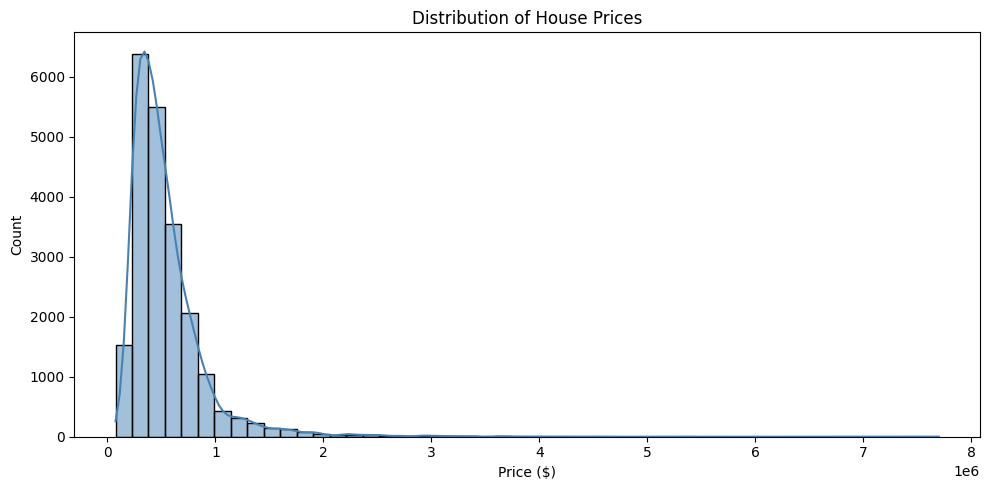

In [7]:
# Distribution of the target variable: house price
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

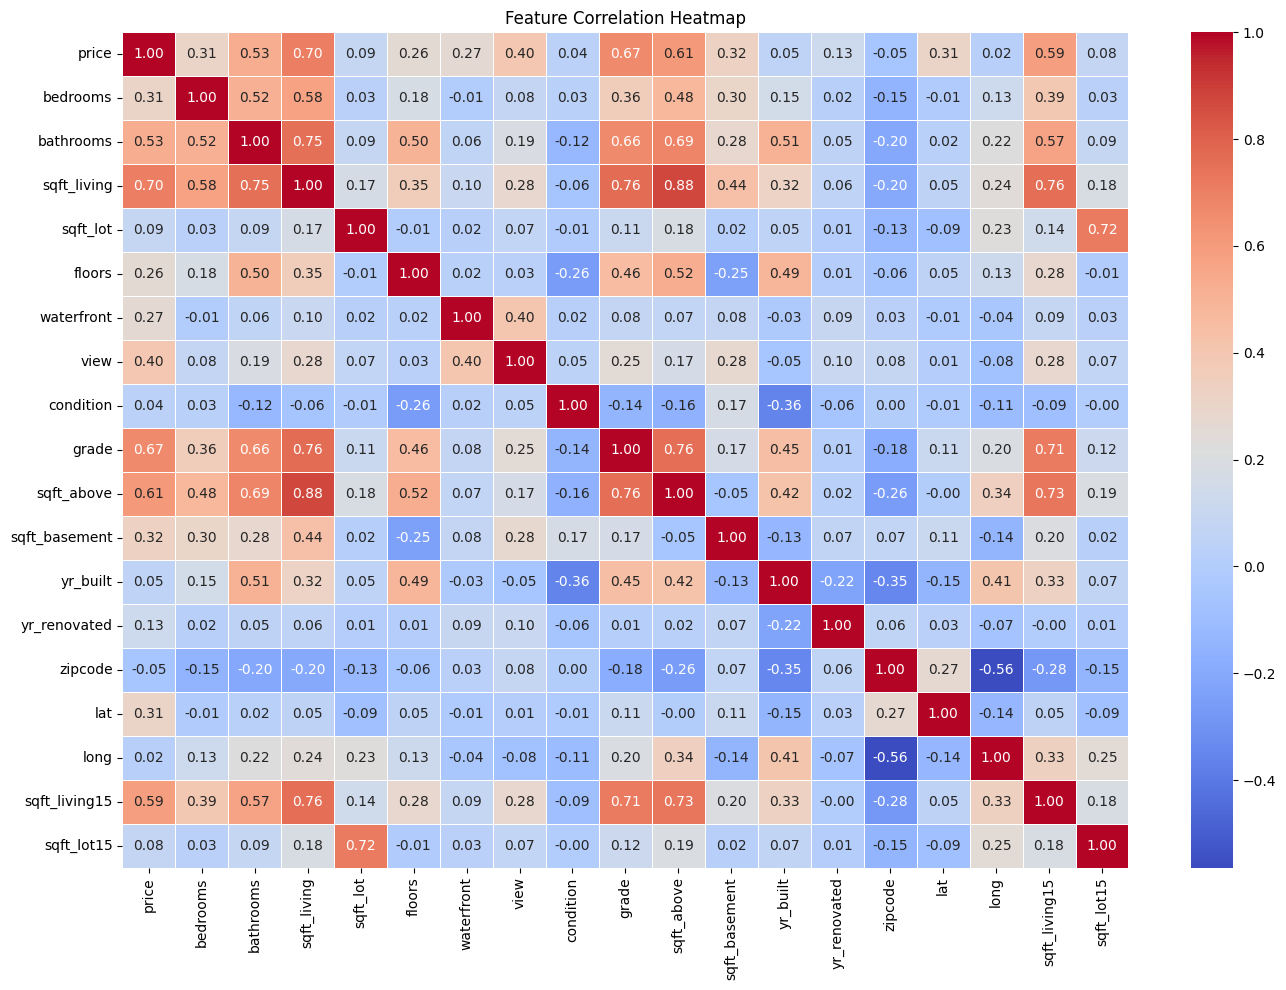

In [8]:
# Correlation heatmap — shows which features are most related to price
plt.figure(figsize=(14, 10))
numeric_df = df.drop(columns=['id', 'date'])  # drop non-numeric columns
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

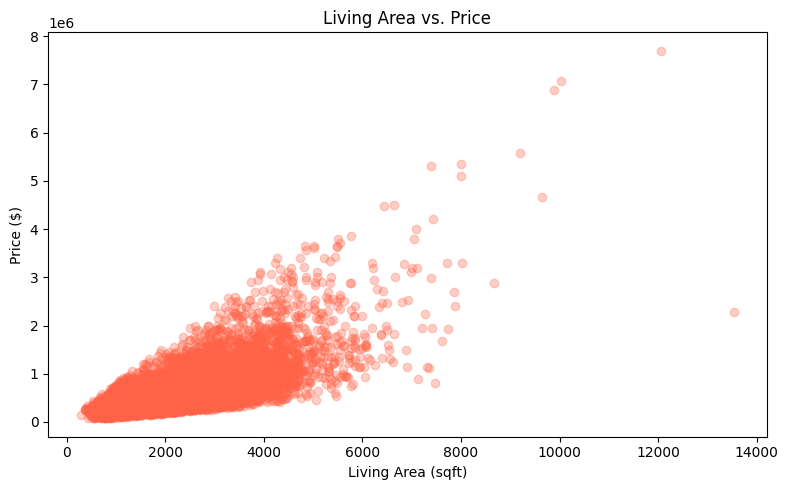

In [9]:
# Scatter plot: living area vs. price — expected strong correlation
plt.figure(figsize=(8, 5))
plt.scatter(df['sqft_living'], df['price'], alpha=0.3, color='tomato')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.title('Living Area vs. Price')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Data Cleaning

In [10]:
# Drop columns that are identifiers or don't add predictive value:
# - 'id': unique identifier, not a feature
# - 'date': we'll extract useful info (month, year) instead of using the raw string
df = df.drop(columns=['id'])

# Convert the date string to a datetime object so we can extract month and year
df['date'] = pd.to_datetime(df['date'])

# Extract month — captures seasonality effects on prices
df['month'] = df['date'].dt.month

# Extract year — captures market trend over time
df['year'] = df['date'].dt.year

# Drop the original date column now that we extracted what we need
df = df.drop(columns=['date'])

print("Updated columns:", df.columns.tolist())

Updated columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'month', 'year']


In [11]:
# Final shape after engineering
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (21613, 21)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,month,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,10,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,12,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,12,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2,2015


## 5. Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=['price'])  # all columns except price
y = df['price']                 # the target we want to predict

# Split into 70% training and 30% testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 15129
Testing samples:  6484


## 6. Feature Scaling

Neural networks train much better when features are on the same scale.
We use **MinMaxScaler** to scale all features to the [0, 1] range.

> ⚠️ We fit the scaler ONLY on training data, then transform both train and test.
> This prevents data leakage from the test set.

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Create the scaler
scaler = MinMaxScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print(f"Feature range after scaling: min={X_train_scaled.min():.2f}, max={X_train_scaled.max():.2f}")

Scaling complete.
Feature range after scaling: min=0.00, max=1.00


## 7. Build the Keras Neural Network Model

Architecture:
- Input layer: matches number of features
- 3 hidden Dense layers with ReLU activation
- Output layer: single neuron (regression → predict a number)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Number of input features
n_features = X_train_scaled.shape[1]

# Build a Sequential model (layers stacked one after another)
model = Sequential([
    # First hidden layer: 19 neurons (same as features), ReLU activation
    Dense(19, activation='relu', input_shape=(n_features,)),

    # Second hidden layer: 19 neurons, ReLU activation
    Dense(19, activation='relu'),

    # Third hidden layer: 19 neurons, ReLU activation
    Dense(19, activation='relu'),

    # Output layer: 1 neuron, no activation (this is regression, not classification)
    Dense(1)
])

# Compile the model:
# - optimizer: Adam (adaptive learning rate, works well in practice)
# - loss: MSE (Mean Squared Error) — standard loss for regression
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Print summary of model architecture
model.summary()

ModuleNotFoundError: No module named 'tensorflow'

## 8. Train the Model

In [ ]:
# Train the model for 400 epochs
# validation_data: monitor performance on test set during training (not used for learning)
# verbose=1: print progress each epoch
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=400,
    batch_size=128,
    verbose=1
)

## 9. Evaluate the Model

In [ ]:
# Plot training loss vs. validation loss over epochs
# If both curves go down together → model is learning well
# If val_loss goes up while train_loss goes down → overfitting
losses = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
losses.plot()
plt.title('Training Loss vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()

# MAE: average absolute difference between predicted and actual price
mae = mean_absolute_error(y_test, y_pred)

# RMSE: square root of average squared differences (penalizes large errors more)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error  (MAE):  ${mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.0f}")

In [ ]:
# Scatter plot: actual vs. predicted prices
# Perfect model → all points on the diagonal line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Save Model and Scaler Weights

We save:
- `model_weights.pkl` — the trained Keras model
- `scaler_weights.pkl` — the fitted scaler (needed to scale new inputs before prediction)

In [ ]:
import pickle

# Save the trained Keras model using pickle
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the fitted scaler so we can reuse it in the API
with open('scaler_weights.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(" model_weights.pkl  — saved successfully")
print(" scaler_weights.pkl — saved successfully")

---

## Summary

| Step | What we did |
|------|-------------|
| EDA | Checked missing values, visualized price distribution and correlations |
| Feature Engineering | Extracted `month` and `year` from date, dropped `id` and `date` |
| Splitting | 70% train / 30% test with `train_test_split` |
| Scaling | Applied `MinMaxScaler` to normalize features to [0, 1] |
| Model | 3-layer Dense Neural Network with ReLU activations |
| Training | Adam optimizer, MSE loss, 400 epochs |
| Evaluation | MAE and RMSE on the test set |
| Saving | Saved model and scaler as `.pkl` files for deployment |